In [1]:
import pandas as pd
# quick fix for PyPSA Arrow issue
pd.options.future.infer_string = False

import matplotlib.pyplot as plt
import pypsa

from pathlib import Path

# Prepare data

## Read input time-series
Input are stored in the `data` folder. 

In [4]:
input_dir = "../data"
input_fl = "micro_grid_inputs.csv"
inputs_full_df = pd.read_csv(Path(input_dir, input_fl), index_col=0)

### Creating inputs
  1. PV capacity factor is created using solar radiation and temperature as inputs
  2. Electricity demand is loaded from the file

In [5]:
import conversion

In [12]:
H = 3     # [m] water height
g = 9.81  # [m/s**2]
rho = 996 # [kg/m3] water density at 30C

In [10]:
# TODO Add the real temperature time-series
T_mean = 30
inputs_full_df["tas"] = T_mean

We created a set of function stored in the file `conversion.py` to easily convert meteorological variables into energy variables

In [8]:
import conversion

In [ ]:
solar_cf = conversion.pv_capacity_factor(
    G = inputs_full_df["ssrd"].values/3600, 
    T_air = inputs_full_df["tas"]._values, 
    gamma=-0.005, NOCT=45.0)
inputs_full_df["solar"] = solar_cf

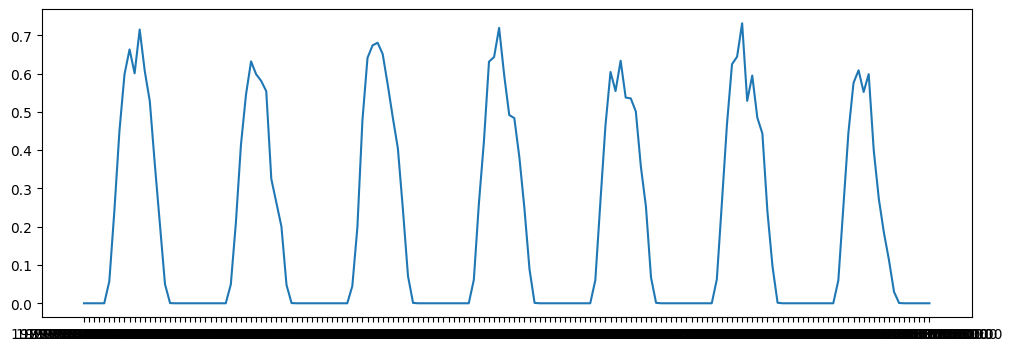

In [14]:
fig = plt.figure(figsize=(12, 4))
plt.plot(inputs_full_df["solar"][0:168])
plt.show()

In [ ]:

# TODO Fix overestimation of the load the inputs
inputs_full_df["load"] = inputs_full_df["load"]

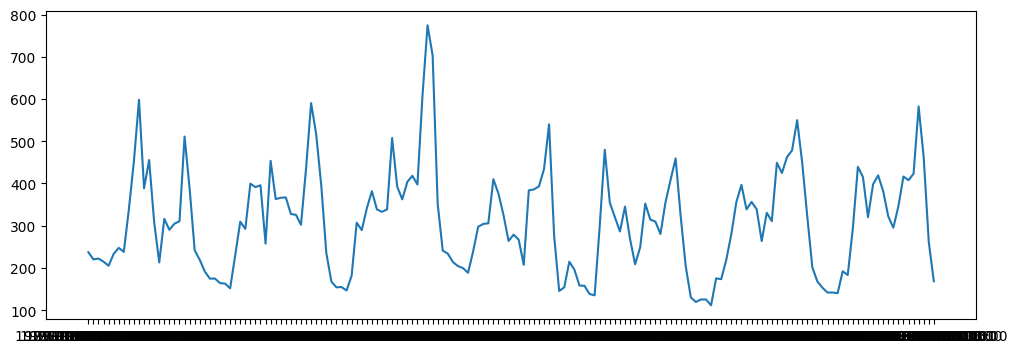

In [15]:
fig = plt.figure(figsize=(12, 4))
plt.plot(inputs_full_df["load"][0:168])
plt.show()

In [16]:
inputs_full_df.head(5)

,inflow,ssrd,load,tas,solar
time,,,,,
1979-01-02 00:00:00,7.890625,0.0,237.254575,30,0.0
1979-01-02 01:00:00,7.875651,0.0,220.373665,30,0.0
1979-01-02 02:00:00,7.860677,0.0,222.213966,30,0.0
1979-01-02 03:00:00,7.845703,0.0,214.868724,30,0.0
1979-01-02 04:00:00,7.830729,0.0,205.222695,30,0.0


## Multi-annual dynamics of inflow 

In [17]:
inputs_full_df["inflow"].mean()

np.float64(7.420212626819239)

In [18]:
inputs_full_df.index = pd.to_datetime(inputs_full_df.index)

In [19]:
inputs_full_df["inflow_monthly"] = (
    inputs_full_df["inflow"]
    .groupby(inputs_full_df.index.to_period("M"))
    .transform("mean")
)
inputs_full_df["inflow_ann"] = (
    inputs_full_df["inflow"]
    .groupby(inputs_full_df.index.to_period("Y"))
    .transform("mean")
)

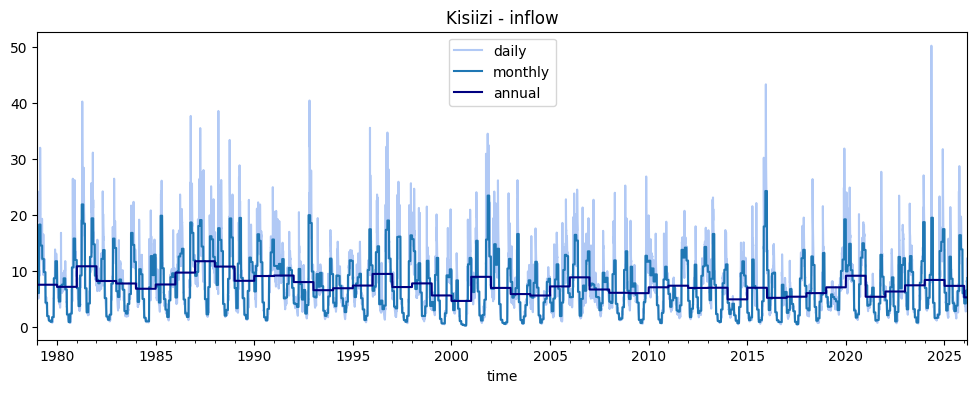

In [21]:
fig, ax = plt.subplots(figsize=(12, 4))
inputs_full_df["inflow"].plot(
    ax=ax, label="daily", alpha=0.5, color="cornflowerblue"
)
inputs_full_df["inflow_monthly"].plot(
    ax=ax, label="monthly"
)
inputs_full_df["inflow_ann"].plot(
    ax=ax, label="annual", color="navy"
)
ax.set_title("Kisiizi - inflow")
ax.legend()

### Test hydro conversion

In [17]:
# NB Design inflow depends on a period of observations
design_inflow = inputs_full_df["inflow"].mean()

In [18]:
inputs_full_df["hydro_eff"] = conversion.hydro_turbine_efficiency(
    q=inputs_full_df["inflow"] / design_inflow,
    turbine_type="francis"
)

In [19]:
#inputs_full_df["hydro"] = (
#    g * H * rho * inputs_full_df["hydro_eff"] * (inputs_full_df["inflow"] / 1e3)
#)
inputs_full_df["hydro"] = (
    g * H * rho * (inputs_full_df["inflow"] / 1e3)
)

In [20]:
inputs_full_df["inflow"].mean()

np.float64(7.420212626819239)

In [21]:
inputs_full_df["hydro"].mean()

np.float64(217.503350176861)

# Build network model

In [22]:
# solar-rooftop,2030,investment,725,EUR/kWel,ETIP PV,,2013
# hydro,2030,investment,2000,EUR/kWel,DIW DataDoc http://hdl.handle.net/10419/80348,,2013

solar_capital_cost = 5 #10
hydro_capital_cost = 700 #300 #1000 #3_600

diesel_capital_cost = 800 #600
fuel_cost = 100 #500

n_max_hours = 24 #24

### Helper functions

In [23]:
def extract_year(merged_df: pd.DataFrame, year: int) -> pd.DataFrame:
    """
    Extract one calendar year from merged_df.

    Assumes merged_df has a datetime column called 'time'.
    """

    df = merged_df.copy()
    df["time"] = pd.to_datetime(df.index)

    year_df = df[df["time"].dt.year.isin(year)].copy()

    return year_df.reset_index(drop=True)

In [24]:
# TODO Add an electrochemical storage
def build_green_microgrid(
        df
    ):
    """
    Optimise a model with considering hydro and solar only
    """
    network = pypsa.Network(snapshots = df.index)
    network.add("Bus", "B1")

    network.add("Generator", "PV",
                carrier = "solar",
                bus="B1",
                capital_cost = solar_capital_cost,
                #p_nom_max = 600_000,
                p_max_pu = df["solar"],
                p_nom_extendable = True,
                )

    # a fake generator which represents unserved energy 
    network.add("Generator", "LoadShedding",
                carrier = "shedding",
                bus="B1",
                capital_cost = 0,
                marginal_cost = 100_000,
                p_nom_extendable = True)

    network.add("StorageUnit", "Hydro",
                bus="B1",
                carrier="hydro",
                max_hours = n_max_hours,
                p_max_pu=1.0,  # dispatch
                p_min_pu=0.0,  # store
                capital_cost = hydro_capital_cost,
                inflow = df["hydro"],       
                p_nom_extendable = True,
                efficiency_dispatch=0.9,
                efficiency_store=0.0,
                cyclic_state_of_charge=True)

    network.add("Load", "L1",
                bus="B1",
                carrier="el_demand",                
                p_set=df["load"])
    return network

In [25]:
def build_microgrid(
        df
    ):
    """
    Optimise a model with considering hydro, solar and diesel
    """
    network = pypsa.Network(snapshots = df.index)
    network.add("Bus", "B1")

    network.add("Generator", "PV",
                carrier = "solar",
                bus="B1",
                capital_cost = solar_capital_cost,
                #p_nom_max = 600_000,
                p_max_pu = df["solar"],
                p_nom_extendable = True,
                )

    # a fake generator which represents unserved energy 
    network.add("Generator", "LoadShedding",
                carrier = "shedding",
                bus="B1",
                capital_cost = 0,
                marginal_cost = 100_000,
                p_nom_extendable = True)

    network.add("StorageUnit", "Hydro",
                bus="B1",
                carrier="hydro",
                max_hours = n_max_hours,
                p_max_pu=1.0,  # dispatch
                p_min_pu=0.0,  # store
                capital_cost = hydro_capital_cost,
                inflow = df["hydro"],       
                p_nom_extendable = True,
                efficiency_dispatch=0.9,
                efficiency_store=0.0,
                cyclic_state_of_charge=True)
    
    network.add("Generator", "diesel",
                carrier = "diesel",
                bus="B1",
                capital_cost = diesel_capital_cost,
                operational_cost = fuel_cost,
                p_nom_extendable = True,
                )    

    network.add("Load", "L1",
                bus="B1",
                carrier="el_demand",                
                p_set=df["load"])
    return network

In [26]:
def plot_microgrid(n):
    """
    Plot disel + RES microgrid
    """
    fig, ax = plt.subplots(figsize=(14, 5))

    dispatch_hourly = pd.DataFrame({
        "PV": n.generators_t["p"]["PV"],
        "diesel": n.generators_t["p"]["diesel"],
        "Hydro": n.storage_units_t["p"]["Hydro"],
        "LoadShedding": -1 * n.generators_t["p"]["LoadShedding"],
    })

    dispatch = dispatch_hourly.resample("D").sum()

    # Stack PV and Hydro
    dispatch[["PV", "Hydro", "diesel"]].plot.area(
        ax=ax,
        linewidth=0,
        color={
            "PV": "#FFB347",       # pastel orange
            "Hydro": "#4DA3FF",    # soft blue
            "diesel": "gray"
        },
    )

    # Plot LoadShedding as negative reddish line
    dispatch["LoadShedding"].plot(
        ax=ax,
        color="#E57373",           # reddish
        linewidth=1.8,
        label="LoadShedding",
    )

    #ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Dispatch")
    ax.set_xlabel("Time")
    ax.set_ylabel("Power")
    ax.legend(loc="best")

    plt.tight_layout()

In [27]:
def plot_green_microgrid(n):
    """
    Plot hydro + PV microgrid
    """
    fig, ax = plt.subplots(figsize=(14, 5))

    dispatch_hourly = pd.DataFrame({
        "PV": n.generators_t["p"]["PV"],
        "Hydro": n.storage_units_t["p"]["Hydro"],
        "LoadShedding": -1 * n.generators_t["p"]["LoadShedding"],
    })

    dispatch = dispatch_hourly.resample("D").sum()

    dispatch[["PV", "Hydro"]].plot.area(
        ax=ax,
        linewidth=0,
        color={
            "PV": "#FFB347",
            "Hydro": "#4DA3FF",
        },
    )

    dispatch["LoadShedding"].plot(
        ax=ax,
        color="#E57373",
        linewidth=1.8,
        label="LoadShedding",
    )

    #ax.axhline(0, color="black", linewidth=0.8)
    #ax.set_title("Dispatch")
    #ax.set_xlabel("Time")
    #ax.set_ylabel("Power")
    #ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

### Building and running models

In [28]:
YEAR_3latest = [2023, 2024, 2025]
YEAR_dry = [2000] # dry year
YEAR_wet = [1987] # wet year

In [29]:
inputs_full_df.head(3)

,inflow,ssrd,load,tas,solar,inflow_monthly,inflow_ann,hydro_eff,hydro
time,,,,,,,,,
1979-01-02 00:00:00,7.890625,0.0,237.254575,30,0.0,6.061013,7.549929,0.912941,231.292209
1979-01-02 01:00:00,7.875651,0.0,220.373665,30,0.0,6.061013,7.549929,0.913054,230.853289
1979-01-02 02:00:00,7.860677,0.0,222.213966,30,0.0,6.061013,7.549929,0.913161,230.414368


In [30]:
inputs_full_df["hydro"].mean()

np.float64(217.503350176861)

In [31]:
inputs_full_df["load"].mean()

np.float64(280.4549582748743)

In [32]:
inputs_3latest_df =(
    extract_year(merged_df=inputs_full_df, year=YEAR_3latest)
    .set_index("time")
)
inputs_dry_df =(
    extract_year(merged_df=inputs_full_df, year=YEAR_dry)
    .set_index("time")
)
inputs_wet_df =(
    extract_year(merged_df=inputs_full_df, year=YEAR_wet)
    .set_index("time")
)

Renewable only micro-grid design

In [33]:
green_microgrid_3latest = (
    build_green_microgrid(df=inputs_3latest_df)
)
green_microgrid_dry = (
    build_green_microgrid(df=inputs_dry_df)
)
green_microgrid_wet = (
    build_green_microgrid(df=inputs_wet_df)
)

In [34]:
microgrid_3latest = (
    build_microgrid(df=inputs_3latest_df)
)
microgrid_dry = (
    build_microgrid(df=inputs_dry_df)
)
microgrid_wet = (
    build_microgrid(df=inputs_wet_df)
)

In [35]:
green_microgrid_3latest.sanitize()
green_microgrid_dry.sanitize()
green_microgrid_wet.sanitize()

microgrid_3latest.sanitize()
microgrid_dry.sanitize()
microgrid_wet.sanitize()

INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Adding 5 missing carriers: ['AC', 'el_demand', 'hydro', 'shedding', 'solar']
INFO:pypsa.components._types.carriers:Assigned colors to 5 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Adding 5 missing carriers: ['AC', 'el_demand', 'hydro', 'shedding', 'solar']
INFO:pypsa.components._types.carriers:Assigned colors to 5 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Adding 5 missing carriers: ['AC', 'el_demand', 'hydro', 'shedding', 'solar']
INFO:pypsa.components._types.carriers:Assigned colors to 5 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Ad

### Example runs

In [36]:
#green_microgrid_3latest.optimize()
green_microgrid_dry.optimize()

/var/folders/qn/vpndfm21795ckkq89np1ckp40000gn/T/ipykernel_15988/2757496295.py:2: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  green_microgrid_dry.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 430.79it/s]
INFO:linopy.io: Writing time: 0.13s


Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-510ee_z4 has 105411 rows; 52707 cols; 189155 nonzeros
Coefficient ranges:
  Matrix  [2e-05, 2e+01]
  Cost    [5e+00, 1e+05]
  Bound   [6e+00, 6e+02]
  RHS     [6e+00, 9e+02]
Presolving model
35728 rows, 35730 cols, 93712 nonzeros  0s
Dependent equations search running on 13472 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
35728 rows, 35730 cols, 93712 nonzeros  0s
Presolve reductions: rows 35728(-69683); columns 35730(-16977); nonzeros 93712(-95443) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.1s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52707 primals, 105411 duals
Objective: 5.49e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


      13955     5.4860470131e+08 Pr: 0(0); Du: 0(2.47383e-10) 4.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-510ee_z4
Model status        : Optimal
Simplex   iterations: 13955
Objective value     :  5.4860470131e+08
P-D objective error :  9.5718632878e-14
HiGHS run time      :          4.05


('ok', 'optimal')

In [37]:
green_microgrid_dry.statistics()

Optimal Capacity  Installed Capacity        Supply  \
Generator   shedding       4.559823e+02                 0.0  4.180495e+03   
            solar          2.385670e+07                 0.0  1.379589e+06   
Load        el_demand      0.000000e+00                 0.0  0.000000e+00   
StorageUnit hydro          1.610243e+04                 0.0  1.078240e+06   

                         Withdrawal  Energy Balance Transmission  \
Generator   shedding   0.000000e+00    4.180495e+03          0.0   
            solar      0.000000e+00    1.379589e+06          0.0   
Load        el_demand  2.462010e+06   -2.462010e+06          0.0   
StorageUnit hydro      0.000000e+00    1.078240e+06          0.0   

                       Capacity Factor   Curtailment  Capital Expenditure  \
Generator   shedding          0.001044  4.001168e+06         0.000000e+00   
            solar             0.000007  4.086678e+10         1.192835e+08   
Load        el_demand              NaN  0.000000e+00         0.000000e+00   
StorageUnit hydro             0.007623  1.403655e+08         1.127170e+07   

                       Operational Expenditure       Revenue   Market Value  
Generator   shedding              4.180495e+08  4.180495e+08  100000.327387  
            solar                 0.000000e+00  1.192835e+08      86.463058  
Load        el_demand             0.000000e+00 -1.083409e+11            NaN  
StorageUnit hydro                 0.000000e+00  1.078035e+11   99981.042145

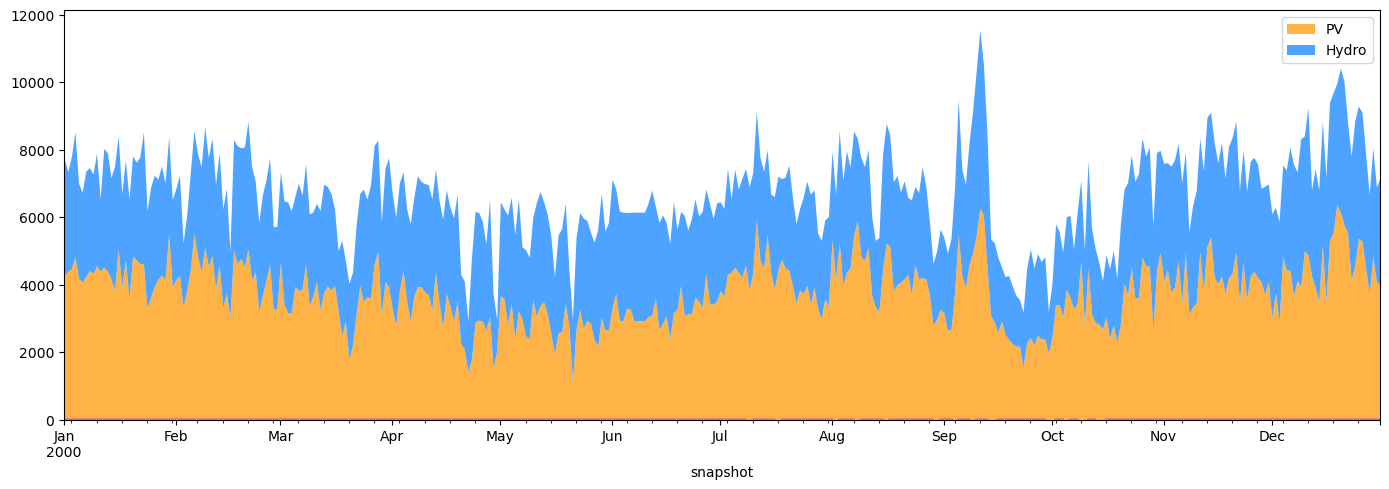

In [38]:
plot_green_microgrid(green_microgrid_dry)

In [39]:
microgrid_dry.optimize()

/var/folders/qn/vpndfm21795ckkq89np1ckp40000gn/T/ipykernel_15988/599927586.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  microgrid_dry.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 481.73it/s]
INFO:linopy.io: Writing time: 0.09s


Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-ukypwdrx has 122980 rows; 61492 cols; 224292 nonzeros
Coefficient ranges:
  Matrix  [2e-05, 2e+01]
  Cost    [5e+00, 1e+05]
  Bound   [6e+00, 6e+02]
  RHS     [6e+00, 9e+02]
Presolving model
48608 rows, 48611 cols, 128256 nonzeros  0s
Dependent equations search running on 17568 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
48608 rows, 48611 cols, 128256 nonzeros  0s
Presolve reductions: rows 48608(-74372); columns 48611(-12881); nonzeros 128256(-96036) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 17568(3.82487e+06) 0.2s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61492 primals, 122980 duals
Objective: 6.80e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


      26862     6.7970819226e+05 Pr: 0(0) 1.9s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-ukypwdrx
Model status        : Optimal
Simplex   iterations: 26862
Objective value     :  6.7970819226e+05
P-D objective error :  2.3978132458e-15
HiGHS run time      :          2.00


('ok', 'optimal')

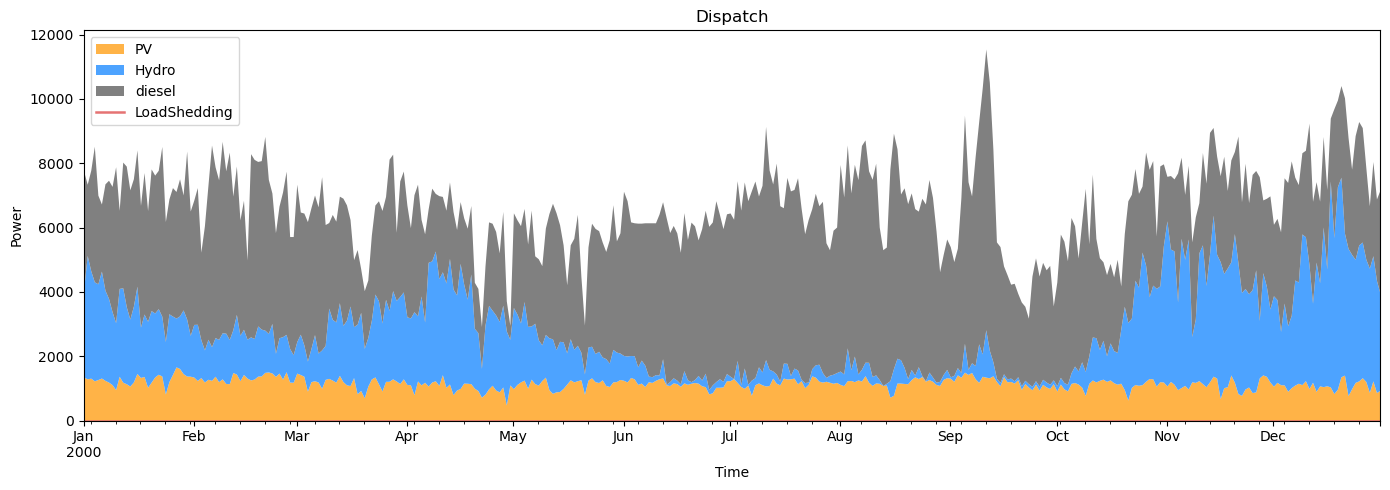

In [40]:
plot_microgrid(microgrid_dry)

In [41]:
microgrid_dry.statistics()

Optimal Capacity  Installed Capacity        Supply  \
Generator   diesel            447.71775                 0.0  1.430493e+06   
            solar             258.99955                 0.0  4.270818e+05   
Load        el_demand           0.00000                 0.0  0.000000e+00   
StorageUnit hydro             457.48428                 0.0  6.044344e+05   

                         Withdrawal  Energy Balance Transmission  \
Generator   diesel     0.000000e+00    1.430493e+06          0.0   
            solar      0.000000e+00    4.270818e+05          0.0   
Load        el_demand  2.462010e+06   -2.462010e+06          0.0   
StorageUnit hydro      0.000000e+00    6.044344e+05          0.0   

                       Capacity Factor   Curtailment  Capital Expenditure  \
Generator   diesel            0.363738  2.502259e+06         358174.19937   
            solar             0.187724  1.660218e+04           1294.99777   
Load        el_demand              NaN  0.000000e+00              0.00000   
StorageUnit hydro             0.150411  3.414108e+06         320238.99512   

                       Operational Expenditure       Revenue  Market Value  
Generator   diesel                         0.0  358174.19937      0.250385  
            solar                          0.0    1294.99777      0.003032  
Load        el_demand                      0.0 -687489.69750           NaN  
StorageUnit hydro                          0.0  328020.50037      0.542690

### Scenario runs

In [42]:
green_microgrid_3latest.optimize()
#green_microgrid_dry.optimize() # if optimized earlier
green_microgrid_wet.optimize()

microgrid_3latest.optimize()
#microgrid_dry.optimize()       # if optimized earlier
microgrid_wet.optimize()

/var/folders/qn/vpndfm21795ckkq89np1ckp40000gn/T/ipykernel_15988/2685417777.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  green_microgrid_3latest.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 259.34it/s]
INFO:linopy.io: Writing time: 0.15s


Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-kzltsqp0 has 315651 rows; 157827 cols; 566425 nonzeros
Coefficient ranges:
  Matrix  [2e-05, 2e+01]
  Cost    [5e+00, 1e+05]
  Bound   [2e+01, 1e+03]
  RHS     [2e+01, 1e+03]
Presolving model
106988 rows, 106990 cols, 280622 nonzeros  0s
Dependent equations search running on 40342 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
106988 rows, 106990 cols, 280622 nonzeros  0s
Presolve reductions: rows 106988(-208663); columns 106990(-50837); nonzeros 280622(-285803) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.5s
      44015     7.4252769470e+06 Pr: 0(0) 3.8s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-kzltsqp0
Model status        : Optim

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 157827 primals, 315651 duals
Objective: 7.43e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.
/var/folders/qn/vpndfm21795ckkq89np1ckp40000gn/T/ipykernel_15988/2685417777.py:3: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  green_microgrid_wet.optimize()
INFO:linopy.model

Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-v12b6hzp has 105123 rows; 52563 cols; 188635 nonzeros
Coefficient ranges:
  Matrix  [2e-05, 2e+01]
  Cost    [5e+00, 1e+05]
  Bound   [5e+01, 1e+03]
  RHS     [3e+01, 1e+03]
Presolving model
35624 rows, 35626 cols, 93440 nonzeros  0s
Dependent equations search running on 13432 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
35624 rows, 35626 cols, 93440 nonzeros  0s
Presolve reductions: rows 35624(-69499); columns 35626(-16937); nonzeros 93440(-95195) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.2s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52563 primals, 105123 duals
Objective: 3.17e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


...

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.
/var/folders/qn/vpndfm21795ckkq89np1ckp40000gn/T/ipykernel_15988/2685417777.py:7: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  microgrid_wet.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 471.32it/s]
INFO:linopy.io: Writing time: 0.09s


Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-a2sur7ua has 122644 rows; 61324 cols; 223676 nonzeros
Coefficient ranges:
  Matrix  [2e-05, 2e+01]
  Cost    [5e+00, 1e+05]
  Bound   [5e+01, 1e+03]
  RHS     [3e+01, 1e+03]
Presolving model
48472 rows, 48475 cols, 127896 nonzeros  0s
Dependent equations search running on 17520 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
48472 rows, 48475 cols, 127896 nonzeros  0s
Presolve reductions: rows 48472(-74172); columns 48475(-12849); nonzeros 127896(-95780) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 17520(5.27379e+06) 0.2s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61324 primals, 122644 duals
Objective: 6.56e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


      26910     6.5591431316e+05 Pr: 0(0) 2.3s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-a2sur7ua
Model status        : Optimal
Simplex   iterations: 26910
Objective value     :  6.5591431316e+05
P-D objective error :  1.0205412152e-14
HiGHS run time      :          2.37


('ok', 'optimal')

#### Statitics

In [43]:
prices_green = ((
    green_microgrid_3latest.objective / green_microgrid_3latest.loads_t["p"].sum()
    ),
    (
        green_microgrid_dry.objective / green_microgrid_dry.loads_t["p"].sum()
    ),
    (
        green_microgrid_wet.objective / green_microgrid_wet.loads_t["p"].sum()
    )
)

In [44]:
prices_moderate = ((
 microgrid_3latest.objective / microgrid_3latest.loads_t["p"].sum()
    ),
    (
     microgrid_dry.objective / microgrid_dry.loads_t["p"].sum()
    ),
    (
     microgrid_wet.objective / microgrid_wet.loads_t["p"].sum()
    )
)

In [45]:
prices_green

(name
 L1    1.006874
 dtype: float64,
 name
 L1    222.828018
 dtype: float64,
 name
 L1    1.292105
 dtype: float64)

In [46]:
prices_moderate

(name
 L1    0.090931
 dtype: float64,
 name
 L1    0.276079
 dtype: float64,
 name
 L1    0.267035
 dtype: float64)